# 4章 オブジェクト指向プログラミングと関数型プログラミング
## 4.1 オブジェクト指向プログラミング

### 4.1.1 クラス、メソッド、属性

● pandasのDataFrameの例

In [21]:
import pandas as pd

my_dict = {"column_1": [1, 2], "column_2": ["a", "b"]}

df = pd.DataFrame(data=my_dict)

In [22]:
df.columns

Index(['column_1', 'column_2'], dtype='object')

In [23]:
df.shape

(2, 2)

In [24]:
df.to_csv("csv_file", index=False)  # "csv_file"という名前のファイルができる

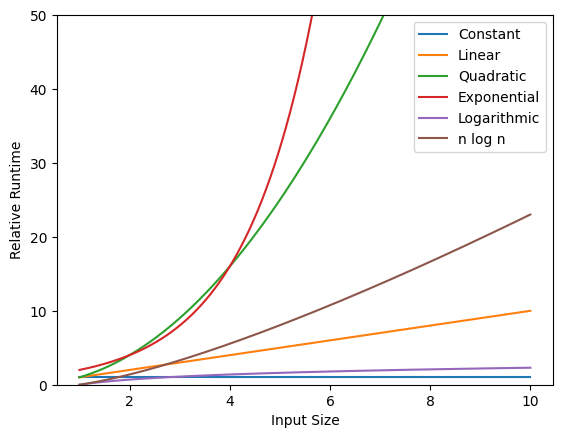

In [26]:
import matplotlib.pyplot as plt
import numpy as np

n = np.linspace(1, 10, 1000)
line_names = [
    "Constant",
    "Linear",
    "Quadratic",
    "Exponential",
    "Logarithmic",
    "n log n",
]
big_o = [np.ones(n.shape), n, n**2, 2**n, np.log(n), n * (np.log(n))]

fig, ax = plt.subplots()  # ❶
fig.set_facecolor("white")  # ❷

ax.set_ylim(0, 50)  # ❸
for i in range(len(big_o)):
    ax.plot(n, big_o[i], label=line_names[i])
ax.set_ylabel("Relative Runtime")
ax.set_xlabel("Input Size")
ax.legend()

fig.savefig("save_path", bbox_inches="tight")  # ❹

### 4.1.2　クラスの定義

In [27]:
# テキストを決められた回数繰り返すもの
class RepeatText:

    def __init__(self, n_repeats):
        self.n_repeats = n_repeats

    def multiply_text(self, some_text):
        print((some_text + " ") * self.n_repeats)

In [28]:
repeat_twice = RepeatText(2)
print(repeat_twice.n_repeats)

2


In [29]:
repeat_twice.multiply_text("hello")

hello hello 


In [31]:
import numpy as np

In [32]:
# 国連の持続可能な開発目標のデータを使う例
class Goal5Data:

    def __init__(self, name, population, women_in_parliament):
        self.name = name
        self.population = population
        self.women_in_parliament = women_in_parliament

    def print_summary(self):
        null_women_in_parliament = len(self.women_in_parliament) - np.count_nonzero(
            self.women_in_parliament
        )
        print(
            f"There are {len(self.women_in_parliament)} data points for Indicator 5.1.1, 'Proportion of seats held by women in national parliaments'."
        )
        print(f"{null_women_in_parliament} are nulls.")

In [33]:
usa = Goal5Data(
    name="USA",
    population=336262544,
    women_in_parliament=[
        13.33,
        14.02,
        14.02,
        14.25,
        14.25,
        14.94,
        15.17,
        16.32,
        16.78,
        17.01,
        16.78,
        16.78,
        16.82,
        17.78,
        18.29,
        19.35,
        19.35,
        19.08,
        19.49,
        23.56,
        23.43,
        27.25,
        27.71,
        29.43,
    ],
)

In [34]:
usa.population

336262544

In [35]:
usa.print_summary()

There are 24 data points for Indicator 5.1.1, 'Proportion of seats held by women in national parliaments'.
0 are nulls.


### 4.1.3　OOPの主要概念

#### 4.1.3.1　継承

##### メモ： `pip install scipy`でインストール

In [36]:
from scipy.stats import linregress

class Goal5TimeSeries(Goal5Data):
    def __init__(self, name, population, women_in_parliament, timestamps):
        super().__init__(name, population, women_in_parliament)
        self.timestamps = timestamps

    def fit_trendline(self):
        result = linregress(self.timestamps, self.women_in_parliament)
        slope = round(result.slope, 3)
        r_squared = round(result.rvalue**2, 3)
        return slope, r_squared

In [37]:
india = Goal5TimeSeries(
    name="India",
    population=1417242151,
    women_in_parliament=[
        9.02,
        9.01,
        8.84,
        8.84,
        8.84,
        8.29,
        8.26,
        8.26,
        9.06,
        9.06,
        10.83,
        10.83,
        11.01,
        11.01,
        11.38,
        11.97,
        11.97,
        11.81,
        11.81,
        12.6,
        14.36,
        14.44,
        14.94,
        15.13,
    ],
    timestamps=[
        2000,
        2001,
        2002,
        2003,
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
        2022,
        2023,
    ],
)

In [38]:
india.print_summary()

There are 24 data points for Indicator 5.1.1, 'Proportion of seats held by women in national parliaments'.
0 are nulls.


In [39]:
india.fit_trendline()

(np.float64(0.292), np.float64(0.869))

## 4.2 関数型プログラミング

### 4.2.1 ラムダ関数とmap()

In [40]:
usa_govt_percentages = [
    13.33,
    14.02,
    14.02,
    14.25,
    14.25,
    14.94,
    15.17,
    16.32,
    16.78,
    17.01,
    16.78,
    16.78,
    16.82,
    17.78,
    18.29,
    19.35,
    19.35,
    19.08,
    19.49,
    23.56,
    23.43,
    27.25,
    27.71,
    29.43,
]

In [41]:
usa_govt_proportions = list(map(lambda x: x / 100, usa_govt_percentages))

In [42]:
print(usa_govt_proportions)

[0.1333, 0.1402, 0.1402, 0.1425, 0.1425, 0.1494, 0.1517, 0.1632, 0.1678, 0.17010000000000003, 0.1678, 0.1678, 0.16820000000000002, 0.1778, 0.18289999999999998, 0.1935, 0.1935, 0.19079999999999997, 0.1949, 0.23559999999999998, 0.2343, 0.2725, 0.2771, 0.2943]


In [ ]:
integer_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

squared_integers = list(map(lambda x: x**2, integer_list))

squared_integers